# Entrenamiento inteligente de BI-RADS — predicción desde hallazgos

**Proyecto BME513 · Universidad de Valparaíso**

Este notebook entrena un modelo para **predecir el BI-RADS a partir de la
descripción de hallazgos**, no para leer el número ya escrito. Esa distinción es
clave: el número "BI-RADS X" suele estar escrito en el informe, y si el modelo lo
ve, aprende a *copiarlo* (fuga de etiqueta) en vez de *razonar*. Por eso el
notebook **enmascara** el número declarado antes de entrenar, de modo que el
modelo deba aprender de los hallazgos — la única versión de la tarea que aporta
valor clínico real (permite detectar posibles mis-categorizaciones).

**Uso:** sube tu CSV (p. ej. `reports_cleaned.csv`) en la celda de carga y luego
`Entorno de ejecución → Ejecutar todo`. Activa antes la GPU en
`Entorno de ejecución → Cambiar tipo de entorno → T4 GPU`.

**Técnicas incluidas:**
- Cierre de 3 fugas de etiqueta: el número declarado (enmascarado), la
  recomendación (proxy fuerte del BI-RADS, se quita) y los duplicados de texto
  (se eliminan para no filtrar entre folds).
- Modelo clínico en español `bsc-bio-ehr-es` (Barcelona Supercomputing Center).
- Manejo del desbalance: pesos de clase + *focal loss* opcional.
- Validación cruzada estratificada (5-fold) con métricas *out-of-fold* honestas.
- Reporte por clase + matriz de confusión.
- Calibración de confianza (*temperature scaling*).
- Guardado del modelo + función de predicción para informes nuevos.

> Nota: este notebook es una línea de investigación *fuera* del sistema de reglas
> del proyecto (que extrae el BI-RADS declarado al 99.9%). Aquí se explora si un
> modelo puede *juzgar* la categoría desde los hallazgos.


## 1. Instalar dependencias

In [1]:
!pip install -q -U transformers datasets accelerate scikit-learn matplotlib seaborn sentencepiece
print("Dependencias instaladas.")

import torch
print("GPU disponible:", torch.cuda.is_available(),
      "| dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.6 MB/s eta 0:00:00
Dependencias instaladas.
GPU disponible: True | dispositivo: Tesla T4


## 2. Configuración

Todo lo ajustable está aquí. Si dejas `columna_texto` / `columna_label` en `None`,
el notebook las detecta solas. Para una corrida rápida de prueba, baja `n_folds`
y `epocas`.

In [2]:
CONFIG = {
    # Modelo base (clínico en español). Alternativas:
    #   "PlanTL-GOB-ES/bsc-bio-ehr-es"        -> clínico, recomendado
    #   "PlanTL-GOB-ES/roberta-base-bne"      -> general español
    #   "dccuchile/bert-base-spanish-wwm-cased" -> BETO general
    "modelo_base": "PlanTL-GOB-ES/bsc-bio-ehr-es",

    "columna_texto": None,     # None = autodetectar (usa el informe completo)
    "columna_label": None,     # None = autodetectar la columna BI-RADS
    "columna_recomendacion": None,  # None = autodetectar (para quitar su fuga)
    "columna_conclusion": None,     # None = autodetectar (para modo solo_hallazgos)

    "enmascarar_birads": True, # elimina la fuga del NÚMERO declarado
    "quitar_recomendacion": True,   # elimina la fuga de la RECOMENDACIÓN (proxy del BI-RADS)
    "solo_hallazgos": False,   # True = usa SOLO hallazgos (quita también la conclusión)
    "deduplicar": True,        # elimina informes de texto idéntico (fuga entre folds)
    "agrupar_clases": False,   # True = agrupa en super-clases clínicas (ver celda 4)

    "max_length": 512,         # tokens por informe (evita truncar la conclusión)
    "epocas": 4,
    "batch_size": 8,
    "learning_rate": 2e-5,
    "n_folds": 5,              # validación cruzada estratificada
    "usar_focal_loss": True,   # True = focal loss; False = CE con pesos de clase
    "focal_gamma": 2.0,
    "seed": 42,
}

import random, numpy as np, torch
random.seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"]); torch.manual_seed(CONFIG["seed"])
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Configuración lista. Dispositivo:", DEVICE)


Configuración lista. Dispositivo: cuda


## 3. Cargar el dataset (sube tu CSV)

In [3]:
from google.colab import files
import pandas as pd, io

print("Sube tu archivo CSV (por ejemplo reports_cleaned.csv)...")
subido = files.upload()
nombre = list(subido.keys())[0]
df = pd.read_csv(io.BytesIO(subido[nombre]))
print(f"\nCargado: {nombre}  ->  {len(df)} filas")
print("Columnas:", list(df.columns))
df.head(3)


Sube tu archivo CSV (por ejemplo reports_cleaned.csv)...


Saving reports_cleaned.csv to reports_cleaned.csv

Cargado: reports_cleaned.csv  ->  4357 filas
Columnas: ['Full_Report', 'Conclusion', 'Recommendations', 'BI-RADS', 'Full_Report_clean', 'Conclusion_clean', 'Recommendations_clean', 'len_report']


,Full_Report,Conclusion,Recommendations,BI-RADS,Full_Report_clean,Conclusion_clean,Recommendations_clean,len_report
0,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,- MAMAS CON ÁREAS DENSAS.-\n- IMAGEN NODULAR D...,- SE SUGIERE ECOGRAFÍA MAMARIA Y CORRELACIÓN C...,0,mamografia digital bilateral craneo-caudal y m...,- mamas con areas densas.- - imagen nodular de...,- se sugiere ecografia mamaria y correlacion c...,938
1,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,- MAMAS DENSAS.\n- CALCIFICACIONES CON CARACTE...,- SE SUGIERE CORRELACIÓN CON ECOGRAFÍA MAMARIA...,2,mamografia digital bilateral craneo-caudal y m...,- mamas densas. - calcificaciones con caracter...,- se sugiere correlacion con ecografia mamaria...,607
2,MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y M...,- IMAGEN NODULAR DE NATURALEZA A DETERMINAR EN...,- SE SUGIERE CORRELACIÓN CON ECOGRAFÍA MAMARIA...,0,mamografia digital bilateral craneo-caudal y m...,- imagen nodular de naturaleza a determinar en...,- se sugiere correlacion con ecografia mamaria...,1060


## 4. Preparar datos: detectar columnas, parsear etiquetas y (opcional) agrupar

Autodetecta la columna de texto (prefiere el informe completo) y la de BI-RADS.
Convierte la etiqueta a entero 0–6. Si `agrupar_clases=True`, colapsa en
super-clases clínicas para mitigar el desbalance extremo de 5 y 6.

In [4]:
import re

def autodetectar(df, cfg):
    cols = list(df.columns)
    def buscar(patrones, defecto=None):
        for p in patrones:
            m = [c for c in cols if c.lower() == p.lower()]
            if m: return m[0]
        for p in patrones:
            m = [c for c in cols if re.search(p, c, re.I)]
            if m: return m[0]
        return defecto
    if cfg["columna_label"] is None:
        cfg["columna_label"] = buscar([r"bi.?rads"], cols[-1])
    if cfg["columna_texto"] is None:
        cfg["columna_texto"] = buscar(
            ["Full_Report_clean", "Full_Report", "full_report", "texto", "report"])
        if cfg["columna_texto"] is None:
            textcols = [c for c in cols if df[c].dtype == object]
            cfg["columna_texto"] = max(textcols, key=lambda c: df[c].astype(str).str.len().mean())
    if cfg["columna_recomendacion"] is None:
        cfg["columna_recomendacion"] = buscar(
            ["Recommendations_clean", "Recommendations", r"recomend"])
    if cfg["columna_conclusion"] is None:
        cfg["columna_conclusion"] = buscar(
            ["Conclusion_clean", "Conclusion", r"conclus"])
    return cfg

CONFIG = autodetectar(df, CONFIG)
print("Columna de texto        :", CONFIG["columna_texto"])
print("Columna de label        :", CONFIG["columna_label"])
print("Columna de recomendación:", CONFIG["columna_recomendacion"])
print("Columna de conclusión   :", CONFIG["columna_conclusion"])

def parse_birads(v):
    m = re.search(r"([0-6])", str(v))
    return int(m.group(1)) if m else None

data = pd.DataFrame({
    "texto": df[CONFIG["columna_texto"]].astype(str),
    "rec": (df[CONFIG["columna_recomendacion"]].astype(str)
            if CONFIG["columna_recomendacion"] else ""),
    "concl": (df[CONFIG["columna_conclusion"]].astype(str)
              if CONFIG["columna_conclusion"] else ""),
    "label_raw": df[CONFIG["columna_label"]].apply(parse_birads),
})
antes = len(data)
data = data.dropna(subset=["label_raw"]).reset_index(drop=True)
data["label_raw"] = data["label_raw"].astype(int)
print(f"\nFilas válidas: {len(data)} (se descartaron {antes - len(data)} sin BI-RADS parseable)")

# FUGA entre folds: eliminar informes de texto idéntico (deja el primero)
if CONFIG["deduplicar"]:
    n0 = len(data)
    data = data.drop_duplicates(subset=["texto"]).reset_index(drop=True)
    print(f"Deduplicación: se eliminaron {n0 - len(data)} informes de texto idéntico -> {len(data)} filas")

# Agrupación opcional en super-clases clínicas
GRUPOS = {0: "incompleto", 1: "benigno", 2: "benigno", 3: "prob_benigno",
          4: "sospechoso", 5: "sospechoso", 6: "maligno"}
if CONFIG["agrupar_clases"]:
    data["clase"] = data["label_raw"].map(GRUPOS)
else:
    data["clase"] = data["label_raw"].astype(str)

print("\nDistribución de clases:")
print(data["clase"].value_counts().sort_index())


Columna de texto        : Full_Report_clean
Columna de label        : BI-RADS
Columna de recomendación: Recommendations_clean
Columna de conclusión   : Conclusion_clean

Filas válidas: 4357 (se descartaron 0 sin BI-RADS parseable)
Deduplicación: se eliminaron 487 informes de texto idéntico -> 3870 filas

Distribución de clases:
clase
0     949
1     435
2    2326
3      87
4      52
5      16
6       5
Name: count, dtype: int64


## 5. Eliminar fugas de etiqueta

Tres fuentes de fuga que se cierran aquí:
1. **El número declarado** ("BI-RADS 4") → se enmascara.
2. **La recomendación** ("se sugiere biopsia" ≈ BI-RADS 4/5) → se quita, porque es
   un proxy fuerte del BI-RADS y dejarla haría que el modelo la lea en vez de
   juzgar los hallazgos.
3. (Opcional, `solo_hallazgos=True`) **la conclusión completa** → se quita para que
   el modelo prediga solo desde la descripción de imágenes.

Se muestra el antes/después y un diagnóstico de cuánto predice la recomendación al
BI-RADS (para justificar por qué hay que quitarla).

In [5]:
# Diagnóstico: ¿la recomendación es un proxy del BI-RADS? (justifica quitarla)
def _cat_rec(r):
    r = str(r).lower()
    if "biopsia" in r or "histolog" in r: return "biopsia"
    if "control anual" in r or "12 mes" in r: return "anual"
    if "6 mes" in r or "corto plazo" in r: return "corto"
    if "ecografia" in r or "complement" in r or "correlacion" in r: return "ecografia"
    return "otro"
if CONFIG["columna_recomendacion"]:
    import pandas as pd
    diag = pd.crosstab(data["rec"].apply(_cat_rec), data["label_raw"])
    print("Fuga de la recomendación (filas=tipo de recomendación, cols=BI-RADS real):")
    print(diag, "\n")

# Máscara del número BI-RADS (incluye subcategorías 4a/4b/4c, dobles dígitos,
# 'o'/'O' como cero y romanos)
PATRON_FUGA = re.compile(
    r"(bi[\s\-_]*rads|categoria|categoría|acr)\s*[:\-]?\s*\(?\s*"
    r"(\d{1,2}[a-c]?|[ivx]{1,4}|o)\b",
    re.IGNORECASE,
)

def quitar_recomendacion(texto, rec):
    """Trunca el texto donde empieza la recomendación (suele ir al final)."""
    rec = str(rec).strip()
    if rec and rec.lower() != "nan" and len(rec) >= 15:
        idx = texto.lower().find(rec.lower()[:40])
        if idx > 0:
            return texto[:idx]
    # Fallback: eliminar oraciones que contengan gatillos de recomendación
    return re.sub(
        r"[^.]*\b(se sugiere|se recomienda|se aconseja|se indica|amerita)\b[^.]*\.?",
        "", texto, flags=re.IGNORECASE)

def solo_hallazgos(texto, concl):
    """Deja el texto ANTES de la conclusión (usa el marcador 'conclusi')."""
    m = re.search(r"conclusi", texto, re.IGNORECASE)
    return texto[:m.start()] if m else texto

def limpiar(row):
    t = row["texto"]
    if CONFIG["quitar_recomendacion"]:
        t = quitar_recomendacion(t, row["rec"])
    if CONFIG["solo_hallazgos"]:
        t = solo_hallazgos(t, row["concl"])
    if CONFIG["enmascarar_birads"]:
        t = PATRON_FUGA.sub("[CATEGORIA]", t)
    return t.strip()

data["texto_modelo"] = data.apply(limpiar, axis=1)

# Verificación: mostrar antes/después
print("Ejemplos de limpieza de fugas:\n")
for _, r in data.head(2).iterrows():
    print("ANTES  :", r["texto"][:220])
    print("DESPUÉS:", r["texto_modelo"][:220])
    print("-"*72)

# Chequeo de residuos: ¿queda alguna mención de número BI-RADS?
resid = data["texto_modelo"].str.contains(r"bi.?rads\s*[:\-]?\s*[0-6]", case=False, regex=True).sum()
print(f"\nInformes con número BI-RADS aún visible (debería ser ~0): {resid}")
largo_prom = data["texto_modelo"].str.len().mean()
print(f"Largo promedio del texto de entrada: {largo_prom:.0f} caracteres")


Fuga de la recomendación (filas=tipo de recomendación, cols=BI-RADS real):
label_raw    0    1     2   3   4   5  6
rec                                     
anual        0   64   432   0   0   0  0
biopsia      8    0     1   0  35  14  0
corto        1    0     0   1   0   0  0
ecografia  922  248  1240  43  14   2  0
otro        18  123   653  43   3   0  5 

Ejemplos de limpieza de fugas:

ANTES  : mamografia digital bilateral craneo-caudal y medio lateral oblicuas no se observan alteraciones cutaneas ni del mamelon.- las mamas se presentan heterogeneamente densas, que podria ocultar algunos nodulos pequenos (tipo 
DESPUÉS: mamografia digital bilateral craneo-caudal y medio lateral oblicuas no se observan alteraciones cutaneas ni del mamelon.- las mamas se presentan heterogeneamente densas, que podria ocultar algunos nodulos pequenos (tipo 
------------------------------------------------------------------------
ANTES  : mamografia digital bilateral craneo-caudal y medio lateral obl

## 6. Mapear etiquetas y preparar el tokenizador

In [6]:
from transformers import AutoTokenizer

clases_unicas = sorted(data["clase"].unique())
label2id = {c: i for i, c in enumerate(clases_unicas)}
id2label = {i: c for c, i in label2id.items()}
data["y"] = data["clase"].map(label2id)
NUM_LABELS = len(clases_unicas)
print("Clases:", label2id, "\nNúmero de clases:", NUM_LABELS)

tokenizer = AutoTokenizer.from_pretrained(CONFIG["modelo_base"])
print("Tokenizador cargado:", CONFIG["modelo_base"])


Clases: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6} 
Número de clases: 7


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/521k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Tokenizador cargado: PlanTL-GOB-ES/bsc-bio-ehr-es


## 7. Componentes de entrenamiento: dataset, focal loss y Trainer con pesos

- `DatasetBirads`: tokeniza al vuelo.
- `FocalLoss`: enfoca el aprendizaje en ejemplos difíciles / clases minoritarias.
- `TrainerPesado`: aplica pesos de clase (inversos a la frecuencia) o focal loss.
- `make_args`: construye `TrainingArguments` de forma robusta entre versiones.

In [7]:
import torch, torch.nn as nn, inspect
from torch.utils.data import Dataset
from transformers import (AutoModelForSequenceClassification, Trainer,
                          TrainingArguments, EarlyStoppingCallback)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score

class DatasetBirads(Dataset):
    def __init__(self, textos, labels, tok, max_len):
        self.textos = list(textos); self.labels = list(labels)
        self.tok = tok; self.max_len = max_len
    def __len__(self): return len(self.textos)
    def __getitem__(self, i):
        enc = self.tok(self.textos[i], truncation=True, padding="max_length",
                       max_length=self.max_len, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__(); self.weight = weight; self.gamma = gamma
    def forward(self, logits, target):
        ce = nn.functional.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

class TrainerPesado(Trainer):
    def __init__(self, *a, class_weights=None, focal=False, gamma=2.0, **k):
        super().__init__(*a, **k)
        self.class_weights = class_weights; self.focal = focal; self.gamma = gamma
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        w = self.class_weights.to(logits.device) if self.class_weights is not None else None
        if self.focal:
            loss = FocalLoss(weight=w, gamma=self.gamma)(logits, labels)
        else:
            loss = nn.functional.cross_entropy(logits, labels, weight=w)
        return (loss, outputs) if return_outputs else loss

def make_args(**kw):
    """Construye TrainingArguments tolerando el cambio eval_strategy/evaluation_strategy."""
    params = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" not in params and "evaluation_strategy" in params:
        if "eval_strategy" in kw:
            kw["evaluation_strategy"] = kw.pop("eval_strategy")
    return TrainingArguments(**kw)

def metricas(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {"macro_f1": f1_score(labels, preds, average="macro")}

def pesos_de_clase(y_train):
    clases = np.unique(y_train)
    w = compute_class_weight("balanced", classes=clases, y=y_train)
    vec = np.ones(NUM_LABELS, dtype="float32")
    for c, val in zip(clases, w):
        vec[c] = val
    return torch.tensor(vec, dtype=torch.float32)

print("Componentes listos.")


Componentes listos.


## 8. Validación cruzada estratificada (entrena y evalúa)

Entrena `n_folds` modelos, cada uno evaluado sobre un fold que no vio. Se juntan
las predicciones *out-of-fold* para métricas honestas (cada informe se predice con
un modelo que no lo entrenó). **Esto es lo que tarda** — con GPU T4, del orden de
30–60 min según configuración.

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

X = data["texto_modelo"].values
y = data["y"].values

skf = StratifiedKFold(n_splits=CONFIG["n_folds"], shuffle=True, random_state=CONFIG["seed"])
oof_pred = np.full(len(y), -1, dtype=int)
oof_prob = np.zeros((len(y), NUM_LABELS), dtype="float32")

for fold, (tr, va) in enumerate(skf.split(X, y), 1):
    print(f"\n===== Fold {fold}/{CONFIG['n_folds']} =====")
    modelo = AutoModelForSequenceClassification.from_pretrained(
        CONFIG["modelo_base"], num_labels=NUM_LABELS,
        id2label=id2label, label2id=label2id)
    ds_tr = DatasetBirads(X[tr], y[tr], tokenizer, CONFIG["max_length"])
    ds_va = DatasetBirads(X[va], y[va], tokenizer, CONFIG["max_length"])
    w = pesos_de_clase(y[tr])

    args = make_args(
        output_dir=f"/content/fold_{fold}",
        num_train_epochs=CONFIG["epocas"],
        per_device_train_batch_size=CONFIG["batch_size"],
        per_device_eval_batch_size=16,
        learning_rate=CONFIG["learning_rate"],
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="macro_f1",
        greater_is_better=True, warmup_ratio=0.1, weight_decay=0.01,
        logging_steps=50, fp16=torch.cuda.is_available(),
        report_to="none", seed=CONFIG["seed"], save_total_limit=1,
    )
    trainer = TrainerPesado(
        model=modelo, args=args, train_dataset=ds_tr, eval_dataset=ds_va,
        compute_metrics=metricas, class_weights=w,
        focal=CONFIG["usar_focal_loss"], gamma=CONFIG["focal_gamma"],
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    pred = trainer.predict(ds_va)
    logits = torch.tensor(pred.predictions)
    probs = torch.softmax(logits, dim=-1).numpy()
    oof_prob[va] = probs
    oof_pred[va] = probs.argmax(-1)
    print(f"Fold {fold} macro-F1:",
          round(f1_score(y[va], oof_pred[va], average="macro"), 4))

macro_global = f1_score(y, oof_pred, average="macro")
print("\n" + "="*60)
print(f"MACRO-F1 out-of-fold (honesto): {macro_global:.4f}")
print("="*60)
print("\nReporte por clase:\n")
print(classification_report(y, oof_pred, target_names=[id2label[i] for i in range(NUM_LABELS)]))



===== Fold 1/5 =====


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: PlanTL-GOB-ES/bsc-bio-ehr-es
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Macro F1
1,2.127963,1.612304,0.409477
2,0.375699,1.192873,0.525909
3,0.438237,0.916433,0.565259
4,1.279424,0.901728,0.546079


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fold 5 macro-F1: 0.6425

MACRO-F1 out-of-fold (honesto): 0.6236

Reporte por clase:

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       949
           1       0.99      0.98      0.98       435
           2       0.99      0.96      0.98      2326
           3       0.60      0.92      0.72        87
           4       0.34      0.29      0.31        52
           5       0.46      0.38      0.41        16
           6       0.00      0.00      0.00         5

    accuracy                           0.95      3870
   macro avg       0.62      0.64      0.62      3870
weighted avg       0.96      0.95      0.95      3870



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 9. Matriz de confusión

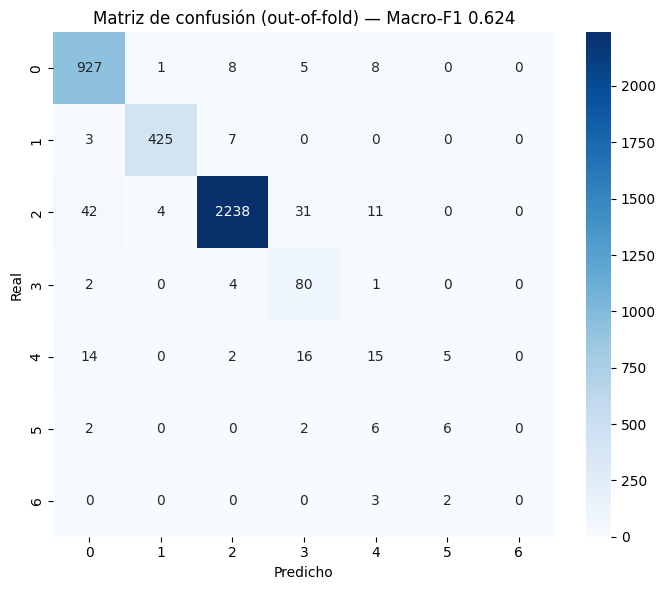

In [9]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, oof_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[id2label[i] for i in range(NUM_LABELS)],
            yticklabels=[id2label[i] for i in range(NUM_LABELS)])
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.title(f"Matriz de confusión (out-of-fold) — Macro-F1 {macro_global:.3f}")
plt.tight_layout(); plt.show()


## 10. Calibración de confianza (temperature scaling)

Ajusta un único parámetro (temperatura) para que las probabilidades del modelo
reflejen mejor su acierto real. Una confianza calibrada es la que tiene sentido
mostrar como indicador en un dashboard.

In [10]:
from scipy.optimize import minimize_scalar
import numpy as np

logits_oof = np.log(np.clip(oof_prob, 1e-9, 1))  # aprox. de logits desde probs

def nll_con_T(T):
    z = logits_oof / T
    z = z - z.max(axis=1, keepdims=True)
    p = np.exp(z); p = p / p.sum(axis=1, keepdims=True)
    return -np.mean(np.log(p[np.arange(len(y)), y] + 1e-9))

res = minimize_scalar(nll_con_T, bounds=(0.5, 5.0), method="bounded")
T_opt = float(res.x)
print(f"Temperatura óptima: {T_opt:.3f}")
print("(>1 = el modelo estaba sobre-confiado; se suaviza la confianza)")


Temperatura óptima: 0.595
(>1 = el modelo estaba sobre-confiado; se suaviza la confianza)


## 11. Entrenar el modelo final con todos los datos y guardarlo

In [11]:
modelo_final = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["modelo_base"], num_labels=NUM_LABELS, id2label=id2label, label2id=label2id)
ds_full = DatasetBirads(X, y, tokenizer, CONFIG["max_length"])
w_full = pesos_de_clase(y)

args_final = make_args(
    output_dir="/content/modelo_final",
    num_train_epochs=CONFIG["epocas"],
    per_device_train_batch_size=CONFIG["batch_size"],
    learning_rate=CONFIG["learning_rate"],
    warmup_ratio=0.1, weight_decay=0.01, logging_steps=50,
    fp16=torch.cuda.is_available(), report_to="none", seed=CONFIG["seed"],
    save_strategy="no",
)
trainer_final = TrainerPesado(
    model=modelo_final, args=args_final, train_dataset=ds_full,
    class_weights=w_full, focal=CONFIG["usar_focal_loss"], gamma=CONFIG["focal_gamma"],
)
trainer_final.train()

RUTA = "/content/modelo_birads_final"
modelo_final.save_pretrained(RUTA); tokenizer.save_pretrained(RUTA)
import json
with open(f"{RUTA}/config_extra.json", "w") as f:
    json.dump({"id2label": id2label, "temperatura": T_opt,
               "enmascarar": CONFIG["enmascarar_birads"]}, f, ensure_ascii=False, indent=2)
print("Modelo guardado en", RUTA)

# Descargar como zip
import shutil
shutil.make_archive("/content/modelo_birads_final", "zip", RUTA)
from google.colab import files as _f
print("Descargando modelo_birads_final.zip ...")
_f.download("/content/modelo_birads_final.zip")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: PlanTL-GOB-ES/bsc-bio-ehr-es
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
50,1.414047
100,1.921235
150,1.686732
200,1.519186
250,0.937842
300,1.212063
350,2.814394
400,0.624840
450,1.915065
500,1.003810


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en /content/modelo_birads_final
Descargando modelo_birads_final.zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Predecir sobre un informe nuevo

Enmascara (si corresponde), tokeniza, predice y devuelve la categoría con su
confianza calibrada.

In [12]:
def _limpiar_para_inferencia(texto):
    t = str(texto)
    if CONFIG["quitar_recomendacion"]:
        t = re.sub(
            r"[^.]*\b(se sugiere|se recomienda|se aconseja|se indica|amerita)\b[^.]*\.?",
            "", t, flags=re.IGNORECASE)
    if CONFIG["enmascarar_birads"]:
        t = PATRON_FUGA.sub("[CATEGORIA]", t)
    return t.strip()

def predecir(texto, aplicar_temperatura=True):
    t = _limpiar_para_inferencia(texto)
    enc = tokenizer(t, truncation=True, max_length=CONFIG["max_length"],
                    return_tensors="pt").to(modelo_final.device)
    modelo_final.eval()
    with torch.no_grad():
        logits = modelo_final(**enc).logits[0].float().cpu().numpy()
    T = T_opt if aplicar_temperatura else 1.0
    z = logits / T; z = z - z.max()
    p = np.exp(z); p = p / p.sum()
    idx = int(p.argmax())
    return {"birads": id2label[idx], "confianza": round(float(p[idx]), 3),
            "distribucion": {id2label[i]: round(float(p[i]), 3) for i in range(NUM_LABELS)}}

ejemplo = "Mama derecha con masa espiculada de 14 mm y microcalcificaciones pleomorfas de aspecto sospechoso."
print("Ejemplo:", ejemplo, "\n")
print(predecir(ejemplo))


Ejemplo: Mama derecha con masa espiculada de 14 mm y microcalcificaciones pleomorfas de aspecto sospechoso. 

{'birads': '5', 'confianza': 0.705, 'distribucion': {'0': 0.003, '1': 0.002, '2': 0.002, '3': 0.002, '4': 0.268, '5': 0.705, '6': 0.019}}


---
### Notas para la defensa

- Lo que este modelo hace es **distinto** del sistema de reglas: no lee el número
  declarado (eso lo hace la regex al 99.9%), sino que intenta **predecir la
  categoría desde los hallazgos** con el número oculto. Compara este Macro-F1
  (out-of-fold, honesto) con el 0.54 de la ablación: cuánto sube es cuánto
  realmente "aprendió" a juzgar, no a copiar.
- El cuello de botella son las clases raras (BI-RADS 5 y 6, con pocos ejemplos).
  Mira su fila en el reporte por clase y en la matriz de confusión: ninguna
  técnica compensa la falta de datos. La mejora estructural es **recolectar o
  generar (con validación clínica) más ejemplos** de esas categorías.
- `agrupar_clases=True` es una alternativa honesta si las clases raras son
  inviables: predecir super-clases clínicas (benigno / sospechoso / ...) con
  buen desempeño es más útil que predecir 7 clases exactas con mal desempeño.
